In [1]:
import sys, json, os
sys.path.append("..")
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
from sklearn.calibration import calibration_curve
from src.final_eval import fit_final_pipeline, evaluate_with_ci

X_train = pd.read_parquet("../data/processed/X_train.parquet")
y_train = pd.read_parquet("../data/processed/y_train.parquet")["_MICHD"]
final = json.load(open("../reports/final_features.json"))["final"]
t = json.load(open("../reports/final_decision.json"))["flag_threshold"]
print(len(final), "features; flag threshold fixed in advance =", round(t, 4))

14 features; flag threshold fixed in advance = 0.0925


In [2]:
pipe = fit_final_pipeline(X_train, y_train, final)
os.makedirs("../models", exist_ok=True)
joblib.dump(pipe, "../models/final_xgb_pipeline.joblib")
print(round(os.path.getsize("../models/final_xgb_pipeline.joblib") / 1e6, 2), "MB")

0.69 MB


In [3]:
X_test = pd.read_parquet("../data/processed/X_test.parquet")
y_test = pd.read_parquet("../data/processed/y_test.parquet")["_MICHD"].values
p_test = pipe.predict_proba(X_test[final])[:, 1]

result = evaluate_with_ci(y_test, p_test, t)
display(result.round(4))
print("mean predicted risk:", round(p_test.mean(), 4), "  observed rate:", round(y_test.mean(), 4))
tn, fp, fn, tp = confusion_matrix(y_test, p_test >= t).ravel()
print(f"confusion matrix at threshold {t:.3f}:  TN={tn}  FP={fp}  FN={fn}  TP={tp}")

result.round(5).to_csv("../reports/final_test_results.csv")
pd.DataFrame({"p": p_test, "y": y_test}, index=X_test.index).to_parquet(
    "../data/processed/test_predictions.parquet")

,estimate,ci_low,ci_high
roc_auc,0.8318,0.8276,0.8354
pr_auc,0.3412,0.3318,0.3512
brier,0.0717,0.0704,0.0729
recall,0.7978,0.7881,0.8054
specificity,0.7102,0.7073,0.7131
precision,0.2213,0.2167,0.2259
flagged_pct,33.7374,33.4252,34.0010


mean predicted risk: 0.0936   observed rate: 0.0936
confusion matrix at threshold 0.093:  TN=58251  FP=23774  FN=1712  TP=6756


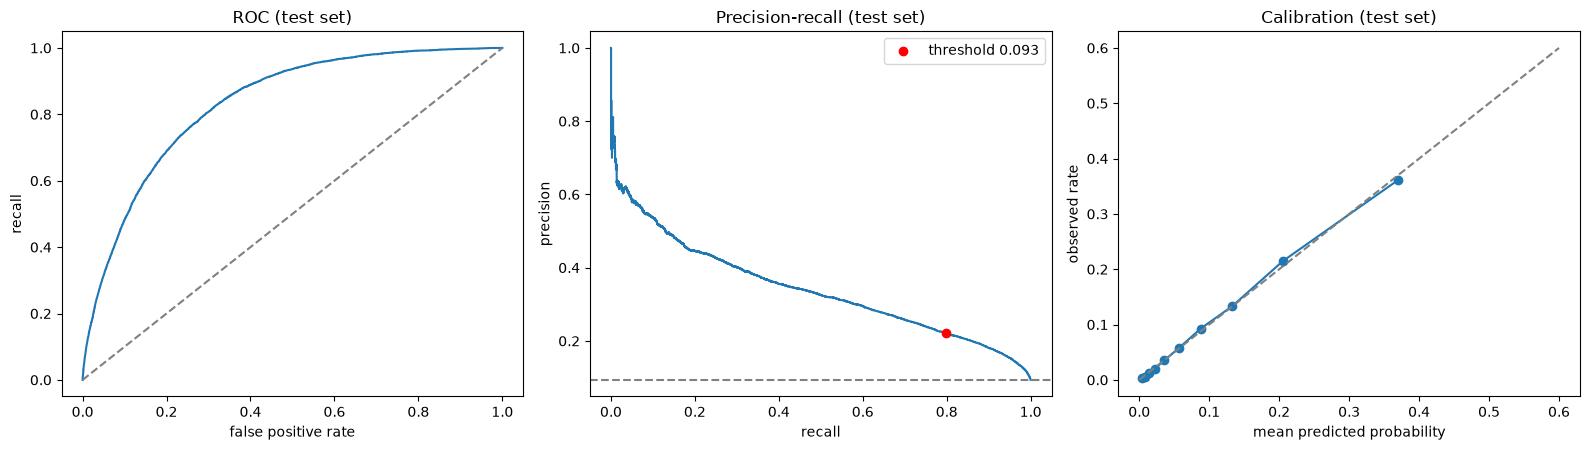

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

fpr, tpr, _ = roc_curve(y_test, p_test)
ax[0].plot(fpr, tpr)
ax[0].plot([0, 1], [0, 1], "--", color="grey")
ax[0].set(title="ROC (test set)", xlabel="false positive rate", ylabel="recall")

pr, rc, _ = precision_recall_curve(y_test, p_test)
ax[1].plot(rc, pr)
ax[1].axhline(y_test.mean(), ls="--", color="grey")
op = result.loc[["recall", "precision"], "estimate"]
ax[1].scatter([op["recall"]], [op["precision"]], color="red", zorder=3, label=f"threshold {t:.3f}")
ax[1].set(title="Precision-recall (test set)", xlabel="recall", ylabel="precision")
ax[1].legend()

frac, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")
ax[2].plot(mean_pred, frac, marker="o")
ax[2].plot([0, 0.6], [0, 0.6], "--", color="grey")
ax[2].set(title="Calibration (test set)", xlabel="mean predicted probability", ylabel="observed rate")

plt.tight_layout()
plt.savefig("../reports/figures/13_test_evaluation.png", dpi=300, bbox_inches="tight")
plt.show()